In [ ]:
# -*- coding: utf-8 -*-
import os
import glob
import json
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import scipy.signal as signal   # Tambahkan ini

# ==============================================================================
# PATHS
# ==============================================================================
DIR_NOISE_INDO = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/indonesia_waveform_master_data/output_data_npypure_3c_noise_9s"
PATH_STEAD_CSV = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'
PATH_STEAD_HDF5 = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.hdf5'
PATH_UUSS_JSON = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json'
PATH_STEAD_BENCH_JSON = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json'

N_SAMPLES = 1000   # Sesuaikan jika terlalu berat
FS = 100.0

# ==============================================================================
# PREPROCESSING SESUAI ZHI GENG (Diperbaiki)
# ==============================================================================
def zhi_geng_preprocess(wave, explicit_norm=None):
    """Preprocessing sesuai paper Zhi Geng"""
    wave = np.asarray(wave, dtype=np.float32).flatten()
    
    if len(wave) == 0:
        return np.zeros(700, dtype=np.float32)
    
    # 1. Detrending
    wave = wave - np.mean(wave)
    
    # 2. Resampling ke 100 Hz (700 sampel)
    if len(wave) != 700:
        wave = signal.resample(wave, 700)
    
    # 3. Normalization
    if explicit_norm is not None:
        norm_val = float(explicit_norm)
    else:
        window_size = min(900, len(wave))
        norm_val = np.max(np.abs(wave[-window_size:]))
        norm_val = norm_val if norm_val > 0 else 1e-8
    
    return wave / norm_val


# ==============================================================================
# LOADING FUNCTIONS
# ==============================================================================
def load_indo_noise(dir_path, n_samples=N_SAMPLES):
    print("[INFO] Loading Indonesia Noise...")
    files = glob.glob(os.path.join(dir_path, "*.npy"))
    np.random.seed(42)
    selected = np.random.choice(files, min(n_samples, len(files)), replace=False)
    
    samples = [np.load(f)[:700, -1] for f in selected]
    print(f"[SUCCESS] Indonesia: {len(samples)} sampel")
    return np.array(samples)


def load_stead_global(csv_path, h5_path, n_samples=N_SAMPLES):
    print("[INFO] Loading STEAD Global Noise...")
    df = pd.read_csv(csv_path, low_memory=False)
    noise_df = df[df['trace_category'] == 'noise'].sample(n=n_samples, random_state=42)
    
    samples = []
    with h5py.File(h5_path, 'r') as f:
        for trace in noise_df['trace_name'].astype(str).values:
            try:
                if trace in f['data']:
                    z = f['data'][trace][()][:700, -1]
                    samples.append(z)
                    if len(samples) >= n_samples:
                        break
            except:
                continue
    print(f"[SUCCESS] STEAD Global: {len(samples)} sampel")
    return np.array(samples)


def load_json_pre_event(json_path, n_samples=N_SAMPLES, name=""):
    print(f"[INFO] Loading {name} Pre-Event Noise...")
    with open(json_path, 'r') as f:
        data = json.load(f)
    keys = list(data.keys())
    np.random.seed(42)
    selected = np.random.choice(keys, min(n_samples, len(keys)), replace=False)
    
    samples = []
    for k in selected:
        try:
            z = np.array(data[k]["Z_noise"])[-700:]
            samples.append(z)
        except:
            continue
    print(f"[SUCCESS] {name}: {len(samples)} sampel")
    return np.array(samples)


# ==============================================================================
# MAIN
# ==============================================================================
if __name__ == "__main__":
    noise_collection = {}
    
    noise_collection['1. Indonesia'] = load_indo_noise(DIR_NOISE_INDO)
    noise_collection['2. STEAD Global'] = load_stead_global(PATH_STEAD_CSV, PATH_STEAD_HDF5)
    noise_collection['3. UUSS'] = load_json_pre_event(PATH_UUSS_JSON, name="UUSS")
    noise_collection['4. STEAD Bench'] = load_json_pre_event(PATH_STEAD_BENCH_JSON, name="STEAD Bench")
    
        # ==============================================================================
    # PSD VISUALISASI - TANPA BAYANGAN
    # ==============================================================================
    plt.figure(figsize=(13, 8))
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
    
    for i, (domain, waves) in enumerate(noise_collection.items()):
        if len(waves) == 0:
            continue
            
        all_psd = []
        for wave in waves:
            processed = zhi_geng_preprocess(wave)
            f, psd = welch(processed, fs=FS, nperseg=256, noverlap=128)
            all_psd.append(psd)
        
        mean_psd = np.mean(all_psd, axis=0)
        
        plt.semilogy(f, mean_psd, label=domain, color=colors[i], 
                     linewidth=2.8, alpha=0.9)

    plt.title("Perbandingan Power Spectral Density (PSD) Noise", 
              weight='bold', fontsize=15, pad=20)
    plt.xlabel("Frekuensi (Hz)", fontsize=13)
    plt.ylabel("Power Spectral Density (V²/Hz)", fontsize=13)
    plt.legend(fontsize=11, loc='upper right')
    plt.grid(True, which="both", linestyle='--', alpha=0.7)
    plt.xlim(0, 50)
    plt.tight_layout()
    
    plt.savefig("PSD_Noise_Comparison_No_Shading.png", dpi=400, bbox_inches='tight')
    plt.show()

In [ ]:
# -*- coding: utf-8 -*-
"""
Perbandingan Spektral PSD Ambient Noise - Adaptasi Code Terbaru
Menggunakan cara loading yang berhasil dari code kamu
"""

import os
import glob
import json
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ==============================================================================
# PATHS
# ==============================================================================
DIR_NOISE_INDO = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/indonesia_waveform_master_data/output_data_npypure_3c_noise_9s"
PATH_STEAD_CSV = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'
PATH_STEAD_HDF5 = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.hdf5'
PATH_UUSS_JSON = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json'
PATH_STEAD_BENCH_JSON = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json'

N_SAMPLES = 1000      # Kamu bisa ubah sesuai kebutuhan
FS = 100.0

# ==============================================================================
# PREPROCESSING (Sesuai Zhi Geng Baseline)
# ==============================================================================
def zhi_geng_standard_preprocessing(wave):
    """Detrending + Max-Absolute Normalization"""
    wave = np.asarray(wave, dtype=np.float32).flatten()
    wave = wave - np.mean(wave)                    # Detrending
    max_val = np.max(np.abs(wave))
    if max_val > 0:
        wave = wave / max_val
    return wave

# ==============================================================================
# LOADING FUNCTIONS (Adaptasi dari code kamu)
# ==============================================================================
def load_indo_noise(dir_path, n_samples=N_SAMPLES):
    print("[INFO] Mengekstraksi Ambient Noise Indonesia...")
    npy_files = glob.glob(os.path.join(dir_path, "*.npy"))
    np.random.seed(42)
    selected = np.random.choice(npy_files, min(n_samples, len(npy_files)), replace=False)
    
    samples = []
    for f in selected:
        try:
            data = np.load(f)
            z = data[:700, -1]          # Ambil kolom terakhir (Z)
            samples.append(z)
        except:
            continue
    print(f"[SUCCESS] Indonesia: {len(samples)} sampel")
    return np.array(samples)


def load_stead_hdf5(csv_path, h5_path, n_samples=N_SAMPLES):
    print("[INFO] Mengekstraksi Ambient Noise STEAD Global...")
    df = pd.read_csv(csv_path, low_memory=False)
    noise_df = df[df['trace_category'] == 'noise'].sample(n=n_samples, random_state=42)
    
    samples = []
    with h5py.File(h5_path, 'r') as f_h5:
        for trace in noise_df['trace_name'].astype(str).values:
            try:
                if trace in f_h5['data']:
                    data = f_h5['data'][trace][()]
                    z = data[:700, -1]          # Kolom terakhir = Z
                    samples.append(z)
                    if len(samples) >= n_samples:
                        break
            except:
                continue
    print(f"[SUCCESS] STEAD Global: {len(samples)} sampel")
    return np.array(samples)


def load_json_pre_event(json_path, n_samples=N_SAMPLES, domain_name=""):
    print(f"[INFO] Mengekstraksi Pre-Event Noise {domain_name}...")
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    keys = list(data.keys())
    np.random.seed(42)
    selected_keys = np.random.choice(keys, min(n_samples, len(keys)), replace=False)
    
    samples = []
    for k in selected_keys:
        try:
            z = np.array(data[k]["Z_noise"])[-700:]
            if len(z) >= 100:
                samples.append(z)
        except:
            continue
    print(f"[SUCCESS] {domain_name}: {len(samples)} sampel")
    return np.array(samples)


# ==============================================================================
# MAIN EXECUTION
# ==============================================================================
if __name__ == "__main__":
    noise_collection = {}
    
    # Load semua domain
    noise_collection['1. Indonesia (Ambient Noise)'] = load_indo_noise(DIR_NOISE_INDO)
    noise_collection['2. STEAD Global (Ambient Noise)'] = load_stead_hdf5(PATH_STEAD_CSV, PATH_STEAD_HDF5)
    noise_collection['3. UUSS (Pre-Event Noise)'] = load_json_pre_event(PATH_UUSS_JSON, domain_name="UUSS")
    noise_collection['4. STEAD Bench (Pre-Event Noise)'] = load_json_pre_event(PATH_STEAD_BENCH_JSON, domain_name="STEAD Bench")
    
    # ==============================================================================
    # PSD CALCULATION + VISUALISASI
    # ==============================================================================
    plt.figure(figsize=(12, 8))
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
    
    for i, (domain, waves) in enumerate(noise_collection.items()):
        if len(waves) == 0:
            continue
        all_psd = []
        for wave in waves:
            processed = zhi_geng_standard_preprocessing(wave)
            freqs, psd = welch(processed, fs=FS, nperseg=256, noverlap=128)
            all_psd.append(psd)
        
        mean_psd = np.mean(all_psd, axis=0)
        std_psd = np.std(all_psd, axis=0)
        
        plt.semilogy(freqs, mean_psd, label=domain, color=colors[i], linewidth=2.5)
        plt.fill_between(freqs, mean_psd - std_psd, mean_psd + std_psd, 
                        color=colors[i], alpha=0.15)
    
    plt.title("Perbandingan Power Spectral Density (PSD) Ambient Noise", 
              weight='bold', fontsize=15, pad=20)
    plt.xlabel("Frekuensi (Hz)", fontsize=13)
    plt.ylabel("Power Spectral Density (V²/Hz)", fontsize=13)
    plt.legend(fontsize=11)
    plt.grid(True, which="both", linestyle='--', alpha=0.6)
    plt.xlim(0, 50)
    plt.tight_layout()
    plt.savefig("PSD_Noise_Comparison_Adapted.png", dpi=400, bbox_inches='tight')
    plt.show()

In [ ]:
# -*- coding: utf-8 -*-
import os
import glob
import json
import h5py
import numpy as np
import pandas as pd
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras

# ==============================================================================
# CONFIGURATION
# ==============================================================================
BASE_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying'
OUTPUT_DIR = os.path.join(BASE_PATH, 'figures_disertasi')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Path Paths

MODEL_PATH = os.path.join(BASE_PATH, 'indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20')

UUSS_JSON = r'/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json'
DIR_NOISE_INDO = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/indonesia_waveform_master_data/output_data_npypure_3c_noise_9s"
PATH_STEAD_CSV = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'
PATH_STEAD_HDF5 = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.hdf5'

# ==============================================================================
# FUNCTIONS
# ==============================================================================
def zhi_geng_normalize(waves):
    max_val = np.max(np.abs(waves))
    return waves / (max_val if max_val != 0 else 1e-8)

def get_embeddings(model, data_waves):
    # Memastikan input (N, 700, 3) diproses dengan benar
    return np.hstack([
        model.predict(data_waves[:, :, 0:1], verbose=0),
        model.predict(data_waves[:, :, 1:2], verbose=0),
        model.predict(data_waves[:, :, 2:3], verbose=0)
    ])

# ==============================================================================
# MAIN PIPELINE
# ==============================================================================
model = keras.models.load_model(MODEL_PATH, compile=False)
noise_collection = {}

# 1. Collect Data
print("[INFO] Mengumpulkan data 3-Domain...")
# UUSS
with open(UUSS_JSON, 'r') as f: uuss_data = json.load(f)
uuss_samples = [zhi_geng_normalize(np.stack([uuss_data[k]["E"], uuss_data[k]["N"], uuss_data[k]["Z"]], axis=-1)[:700]) 
                for k in list(uuss_data.keys())[:500]]
noise_collection['UUSS (In-Distribution)'] = np.array(uuss_samples)

# Indonesia
files = glob.glob(os.path.join(DIR_NOISE_INDO, "*.npy"))
raw_indo = np.array([zhi_geng_normalize(np.load(f)[:700]) for f in np.random.choice(files, 500, replace=False)])
noise_collection['Indonesia (Ambient)'] = raw_indo

# STEAD
df = pd.read_csv(PATH_STEAD_CSV, low_memory=False)
traces = df[df['trace_category'] == 'noise'].sample(500)['trace_name'].values
with h5py.File(PATH_STEAD_HDF5, 'r') as f:
    raw_stead = np.array([zhi_geng_normalize(f['data'][t][()][:700]) for t in traces if t in f['data']])
    noise_collection['STEAD (Ambient)'] = raw_stead

# 2. Extract & Embed
print("[INFO] Mengekstraksi fitur laten...")
X_list, labels = [], []
for domain, waves in noise_collection.items():
    X_list.append(get_embeddings(model, waves))
    labels.extend([domain] * len(waves))

# 3. UMAP Reduction
print("[INFO] Running UMAP Analysis...")
reducer = umap.UMAP(n_neighbors=20, min_dist=0.1, n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(np.vstack(X_list))

# 4. Visualization (Publication Ready)
plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding_2d[:, 0], y=embedding_2d[:, 1], hue=labels, style=labels, palette="deep", alpha=0.7)
plt.title("Latent Space Divergence: UUSS vs. Ambient Noise (Indo & STEAD)", fontsize=14, weight='bold')
plt.xlabel("UMAP Dimension 1", fontsize=12)
plt.ylabel("UMAP Dimension 2", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save output
plot_path = os.path.join(OUTPUT_DIR, "latent_space_divergence.png")
plt.savefig(plot_path, dpi=300)
print(f"[INFO] Plot tersimpan di: {plot_path}")
plt.show()

In [ ]:
# -*- coding: utf-8 -*-
import os

uuss_json_path = r'/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json'
print(f"[DEBUG] Mengecek keberadaan file: {uuss_json_path}")

if os.path.exists(uuss_json_path):
    print("[SUCCESS] File ditemukan!")
else:
    print("[ERROR] File tidak ditemukan di path tersebut.")
    
    # Memeriksa folder induknya
    parent_dir = os.path.dirname(uuss_json_path)
    print(f"[DEBUG] Mengecek folder induk: {parent_dir}")
    
    if os.path.exists(parent_dir):
        print(f"[INFO] Folder induk ada. Isi folder adalah: {os.listdir(parent_dir)}")
    else:
        print("[CRITICAL] Folder induk juga tidak ditemukan. Mohon cek kembali struktur folder di finder.")

In [ ]:
# -*- coding: utf-8 -*-
import os
import glob
import json
import h5py
import numpy as np
import pandas as pd
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras

# ==============================================================================
# PATH & CONFIG
# ==============================================================================
# Pastikan path ini menunjuk ke file benchmark noise, bukan event
UUSS_JSON = r'/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json'
DIR_NOISE_INDO = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/indonesia_waveform_master_data/output_data_npypure_3c_noise_9s"
PATH_STEAD_CSV = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'
PATH_STEAD_HDF5 = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.hdf5'
MODEL_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20'

model = keras.models.load_model(MODEL_PATH, compile=False)

def zhi_geng_normalize(waves):
    max_val = np.max(np.abs(waves))
    return waves / (max_val if max_val != 0 else 1e-8)

def get_embeddings(model, data_waves):
    return np.hstack([
        model.predict(data_waves[:, :, 0:1], verbose=0),
        model.predict(data_waves[:, :, 1:2], verbose=0),
        model.predict(data_waves[:, :, 2:3], verbose=0)
    ])

# ==============================================================================
# DATA COLLECTION: NOISE vs NOISE vs NOISE
# ==============================================================================
print("[INFO] Mengumpulkan data 3-Domain (Semua adalah Noise)...")
noise_collection = {}

# 1. UUSS Noise
with open(UUSS_JSON, 'r') as f: uuss_data = json.load(f)
uuss_samples = []
print("[INFO] Mengumpulkan data UUSS Noise dengan sinkronisasi panjang...")
uuss_samples = []

for k in list(uuss_data.keys())[:500]:
    if "E_noise" in uuss_data[k]:
        # Konversi ke numpy array terlebih dahulu agar bisa di-slice
        e = np.array(uuss_data[k]["E_noise"])
        n = np.array(uuss_data[k]["N_noise"])
        z = np.array(uuss_data[k]["Z_noise"])
        
        # Ambil 700 sampel terakhir (atau sesuai panjang yang disepakati)
        # Slicing [-700:] akan mengambil 700 sampel terakhir. 
        # Jika data kurang dari 700, ini akan mengambil semua (perlu pengecekan)
        e = e[-700:]
        n = n[-700:]
        z = z[-700:]
        
        # Validasi: Pastikan ketiganya memiliki bentuk yang sama persis
        if e.shape == n.shape == z.shape and e.shape[0] == 700:
            wave = np.stack([e, n, z], axis=-1)
            uuss_samples.append(zhi_geng_normalize(wave))
        else:
            # Lewati jika data tidak konsisten atau kurang dari 700
            continue

noise_collection['UUSS (Noise)'] = np.array(uuss_samples)
print(f"[INFO] Berhasil memuat {len(uuss_samples)} sampel noise UUSS.")

# 2. Indonesia (Sudah Noise)
files = glob.glob(os.path.join(DIR_NOISE_INDO, "*.npy"))
raw_indo = np.array([zhi_geng_normalize(np.load(f)[:700]) for f in np.random.choice(files, 500, replace=False)])
noise_collection['Indonesia (Ambient)'] = raw_indo

# 3. STEAD Noise
df = pd.read_csv(PATH_STEAD_CSV, low_memory=False)
traces = df[df['trace_category'] == 'noise'].sample(500)['trace_name'].values
with h5py.File(PATH_STEAD_HDF5, 'r') as f:
    raw_stead = np.array([zhi_geng_normalize(f['data'][t][()][:700]) for t in traces if t in f['data']])
    noise_collection['STEAD (Ambient)'] = raw_stead

# ==============================================================================
# UMAP & PLOT
# ==============================================================================
X_list, labels = [], []
for domain, waves in noise_collection.items():
    X_list.append(get_embeddings(model, waves))
    labels.extend([domain] * len(waves))

reducer = umap.UMAP(n_neighbors=20, min_dist=0.1, n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(np.vstack(X_list))

plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding_2d[:, 0], y=embedding_2d[:, 1], hue=labels, style=labels, palette="viridis", alpha=0.7)
plt.title("Analisis Ruang Laten: Noise vs Noise (Cross-Domain Robustness)", weight='bold')
plt.show()

In [ ]:
# -*- coding: utf-8 -*-
import json
import numpy as np
import glob
import os
from scipy.signal import welch
import matplotlib.pyplot as plt

# ==============================================================================
# CONFIGURATION
# ==============================================================================
DATA_MAP = {
    "UUSS": r'/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json',
    "STEAD": '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json',
    "Ukraine": '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ Ukraine 3C_ test n1335 r100 sdb8-956/Ukraine data, test n1335 r100 sdb8-956.json'
}
DIR_NOISE_INDO = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/indonesia_waveform_master_data/output_data_npypure_3c_noise_9s"

def zhi_geng_normalize(wave):
    max_val = np.max(np.abs(wave))
    return wave / (max_val if max_val != 0 else 1e-8)

def load_json_noise_z(path):
    with open(path, 'r') as f:
        data = json.load(f)
    samples = []
    keys = list(data.keys())
    suffix = "_noise" if "Z_noise" in data[keys[0]] else ""
    
    for k in keys[:300]: 
        try:
            # Ambil hanya kanal Z
            z = np.array(data[k][f"Z{suffix}"])
            if z.shape[0] >= 700:
                samples.append(zhi_geng_normalize(z[-700:]))
        except KeyError:
            continue
    return np.array(samples)

def load_indo_noise_z(dir_path):
    files = glob.glob(os.path.join(dir_path, "*.npy"))
    selected_files = np.random.choice(files, min(300, len(files)), replace=False)
    # Ambil index 2 (Z) dari file .npy yang bentuknya (700, 3)
    samples = [zhi_geng_normalize(np.load(f)[-700:, 2]) for f in selected_files]
    return np.array(samples)

# ==============================================================================
# ANALISIS SPEKTRAL Z-CHANNEL
# ==============================================================================
all_noise_data = {}
for name, path in DATA_MAP.items():
    all_noise_data[name] = load_json_noise_z(path)
all_noise_data["Indonesia"] = load_indo_noise_z(DIR_NOISE_INDO)

plt.figure(figsize=(12, 7))
for name, waves in all_noise_data.items():
    all_psd = []
    for wave in waves:
        f, psd = welch(wave, fs=100, nperseg=256)
        all_psd.append(psd)
    plt.semilogy(f, np.mean(all_psd, axis=0), label=name, linewidth=2)

plt.title("Perbandingan Spektral Kanal Vertikal (Z): Noise", weight='bold', fontsize=14)
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Power Spectral Density (V^2/Hz)")
plt.legend()
plt.grid(True, which="both", linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# -*- coding: utf-8 -*-
import json
import numpy as np
import glob
import os
import h5py
import pandas as pd
from scipy.signal import welch
import matplotlib.pyplot as plt

# ==============================================================================
# CONFIGURATION
# ==============================================================================
DATA_MAP = {
    "UUSS": r'/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json',
    "STEAD_Bench": '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json',
    "Ukraine": '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ Ukraine 3C_ test n1335 r100 sdb8-956/Ukraine data, test n1335 r100 sdb8-956.json'
}

# Path Data Baru
STEAD_CSV = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'
STEAD_HDF5 = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.hdf5'

DIR_NOISE_INDO = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/indonesia_waveform_master_data/output_data_npypure_3c_noise_9s"

def zhi_geng_normalize(wave):
    max_val = np.max(np.abs(wave))
    return wave / (max_val if max_val != 0 else 1e-8)

# Fungsi untuk membaca JSON benchmark yang sudah ada
def load_json_noise_z(path):
    with open(path, 'r') as f:
        data = json.load(f)
    samples = []
    keys = list(data.keys())
    suffix = "_noise" if "Z_noise" in data[keys[0]] else ""
    for k in keys[:300]: 
        try:
            z = np.array(data[k][f"Z{suffix}"])
            if z.shape[0] >= 700:
                samples.append(zhi_geng_normalize(z[-700:]))
        except KeyError: continue
    return np.array(samples)

# FUNGSI BARU: Membaca dari HDF5 & CSV STEAD
def load_stead_large_noise_z(csv_path, h5_path, n_samples=300):
    print(f"[INFO] Memproses STEAD Large Dataset dari HDF5...")
    df = pd.read_csv(csv_path, usecols=['trace_name', 'trace_category'])
    noise_names = df[df['trace_category'] == 'noise']['trace_name'].sample(n=n_samples, random_state=42)
    
    samples = []
    with h5py.File(h5_path, 'r') as f:
        data_group = f['data']
        for name in noise_names:
            if name in data_group:
                wave = data_group[name][()] # Format biasanya (samples, 3)
                # Ambil kanal Z (indeks 2)
                z = wave[-700:, 2]
                samples.append(zhi_geng_normalize(z))
    return np.array(samples)

def load_indo_noise_z(dir_path):
    files = glob.glob(os.path.join(dir_path, "*.npy"))
    selected_files = np.random.choice(files, min(300, len(files)), replace=False)
    samples = [zhi_geng_normalize(np.load(f)[-700:, 2]) for f in selected_files]
    return np.array(samples)

# ==============================================================================
# EKSEKUSI ANALISIS
# ==============================================================================
all_noise_data = {}

# 1. Load semua benchmark JSON
for name, path in DATA_MAP.items():
    all_noise_data[name] = load_json_noise_z(path)

# 2. Load STEAD Besar (HDF5+CSV)
all_noise_data["STEAD_Full"] = load_stead_large_noise_z(STEAD_CSV, STEAD_HDF5)

# 3. Load Indonesia
all_noise_data["Indonesia"] = load_indo_noise_z(DIR_NOISE_INDO)

# Plotting
plt.figure(figsize=(12, 7))
for name, waves in all_noise_data.items():
    all_psd = []
    for wave in waves:
        f, psd = welch(wave, fs=100, nperseg=256)
        all_psd.append(psd)
    plt.semilogy(f, np.mean(all_psd, axis=0), label=name, linewidth=2)

plt.title("Perbandingan Spektral: data noise (Z)", weight='bold', fontsize=14)
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Power Spectral Density (V^2/Hz)")
plt.legend()
plt.grid(True, which="both", linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# -*- coding: utf-8 -*-
import json
import random

# Daftar semua path JSON benchmark
DATA_MAP = {
    "UUSS": r'/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json',
    "STEAD_Bench": '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json',
    "Ukraine": '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ Ukraine 3C_ test n1335 r100 sdb8-956/Ukraine data, test n1335 r100 sdb8-956.json'
}

def inspect_json_structure(domain_name, path, num_samples=3):
    print(f"============================================================")
    print(f"[INFO] Membedah struktur JSON: {domain_name}")
    print(f"Path: {path}")
    print(f"============================================================\n")
    
    try:
        with open(path, 'r') as f:
            data = json.load(f)
            
        keys = list(data.keys())
        random.shuffle(keys)
        sample_keys = keys[:num_samples]
        
        for i, k in enumerate(sample_keys):
            print(f"--- {domain_name} | Sampel {i+1} | Trace ID: {k} ---")
            trace_data = data[k]
            
            # Ekstrak metadata (abaikan list/array sinyal agar output rapi)
            metadata = {key: val for key, val in trace_data.items() if not isinstance(val, list)}
            
            # Ekstrak nama-nama key yang berisi array sinyal
            array_keys = [key for key, val in trace_data.items() if isinstance(val, list)]
            
            print("Metadata:")
            print(json.dumps(metadata, indent=4))
            print(f"Array Saluran Sinyal: {array_keys}\n")
    except FileNotFoundError:
        print(f"[ERROR] File tidak ditemukan: {path}\n")
    except Exception as e:
        print(f"[ERROR] Terjadi kesalahan saat membaca {domain_name}: {e}\n")

if __name__ == "__main__":
    for domain, path in DATA_MAP.items():
        inspect_json_structure(domain, path)

In [ ]:
# -*- coding: utf-8 -*-
import json
import numpy as np
import glob
import os
import h5py
import pandas as pd
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================================================================
# 1. CONFIGURATION & PATHS
# ==============================================================================
MODEL_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20'

DATA_MAP = {
    "UUSS": r'/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json',
    "STEAD_Bench": '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json',
    "Ukraine": '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ Ukraine 3C_ test n1335 r100 sdb8-956/Ukraine data, test n1335 r100 sdb8-956.json'
}

STEAD_CSV = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'
STEAD_HDF5 = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.hdf5'
DIR_NOISE_INDO = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/indonesia_waveform_master_data/output_data_npypure_3c_noise_9s"

TARGET_SAMPLES = 5000 

# ==============================================================================
# 2. DATA LOADING & PREPROCESSING (STRICTLY ZHI GENG)
# ==============================================================================
def zhi_geng_preprocess(wave, explicit_norm=None):
    """
    Sesuai prosedur MCU-Quake: Detrending -> Normalisasi.
    Jika explicit_norm disediakan (dari JSON Zhi Geng), gunakan itu.
    Jika tidak, normalisasi menggunakan max(abs) dari sinyal itu sendiri (sesuai real-time window).
    """
    # 1. Detrending
    wave = wave - np.mean(wave, axis=0) 
    
    # 2. Normalization
    if explicit_norm is not None:
        norm_val = explicit_norm
    else:
        norm_val = np.max(np.abs(wave))
        
    norm_val = norm_val if norm_val != 0 else 1e-8
    return wave / norm_val

def load_json_noise_z(path, target, domain_name):
    print(f"[INFO] Mengekstrak Z_noise secara ketat dari JSON: {domain_name}...")
    with open(path, 'r') as f:
        data = json.load(f)
        
    samples = []
    keys = list(data.keys())
    np.random.shuffle(keys) 
    
    for k in keys: 
        trace_data = data[k]
        if "Z_noise" in trace_data:
            try:
                z_noise = np.array(trace_data["Z_noise"])
                if z_noise.shape[0] >= 700:
                    # Ambil nilai 'norm' eksak buatan Zhi Geng
                    exact_norm = trace_data["norm"] 
                    
                    z_processed = zhi_geng_preprocess(z_noise[-700:], explicit_norm=exact_norm)
                    samples.append(z_processed)
                    
                    if len(samples) == target:
                        break
            except Exception: continue
    return np.array(samples)

def load_stead_large_noise_z(csv_path, h5_path, target):
    print(f"[INFO] Mengekstrak sampel noise mentah dari STEAD 1.2M...")
    buffer_n = int(target * 3) 
    df = pd.read_csv(csv_path, usecols=['trace_name', 'trace_category'])
    noise_names = df[df['trace_category'] == 'noise']['trace_name'].sample(n=buffer_n, random_state=42).tolist()
    
    samples = []
    with h5py.File(h5_path, 'r') as f:
        data_group = f['data']
        for name in noise_names:
            if name in data_group:
                # Sumbu vertikal (Z) dari HDF5
                wave = data_group[name][()] 
                z_noise = wave[:, 2]
                
                # Preprocess mengikuti prosedur
                z_processed = zhi_geng_preprocess(z_noise)
                samples.append(z_processed[-700:])
                
                if len(samples) == target: break
    return np.array(samples)

def load_indo_noise_z(dir_path, target):
    print(f"[INFO] Mengekstrak sampel noise mentah Indonesia...")
    files = glob.glob(os.path.join(dir_path, "*.npy"))
    np.random.shuffle(files) 
    
    samples = []
    for f in files:
        # Sumbu vertikal (Z) dari .npy 3 komponen
        wave = np.load(f) 
        if wave.shape[0] >= 700:
            z_noise = wave[:, 2]
            
            # Preprocess mengikuti prosedur
            z_processed = zhi_geng_preprocess(z_noise)
            samples.append(z_processed[-700:])
            
            if len(samples) == target: break
    return np.array(samples)

# --- Proses Penarikan Data ---
all_noise_data = {}
for name, path in DATA_MAP.items():
    all_noise_data[name] = load_json_noise_z(path, TARGET_SAMPLES, name)

all_noise_data["STEAD_Full"] = load_stead_large_noise_z(STEAD_CSV, STEAD_HDF5, TARGET_SAMPLES)
all_noise_data["Indonesia"] = load_indo_noise_z(DIR_NOISE_INDO, TARGET_SAMPLES)

# ==============================================================================
# 3. TENSORFLOW INFERENCE
# ==============================================================================
def get_official_embeddings(model_folder, data_dict):
    print(f"\n[INFO] Memuat TensorFlow SavedModel dari: {model_folder}")
    model = tf.saved_model.load(model_folder)
    infer = model.signatures["serving_default"]
    
    latent_results = {}
    for domain, waves in data_dict.items():
        if len(waves) == 0: continue
        print(f"[INFO] Ekstraksi representasi laten untuk {domain}...")
        data_tensor = tf.convert_to_tensor(waves.reshape(-1, 700, 1), dtype=tf.float32)
        outputs = infer(data_tensor)
        output_key = list(outputs.keys())[0]
        latent_results[domain] = outputs[output_key].numpy().flatten()
    return latent_results

latent_results = get_official_embeddings(MODEL_PATH, all_noise_data)
print("\n=== STATISTIK LATENT CODE ===")
for domain, codes in latent_results.items():
    print(f"{domain:15} | Mean: {np.mean(codes):.3f} | Std: {np.std(codes):.3f} | "
          f"Shift from Noise Center: {np.mean(codes) + 5.01:.2f}")
# ==============================================================================
# 4. VISUALISASI RUANG LATEN
# ==============================================================================
plt.figure(figsize=(12, 7))
for domain, codes in latent_results.items():
    sns.kdeplot(codes, label=f"{domain} (n={len(codes)})", fill=True, alpha=0.3, linewidth=2)

plt.axvline(x=-5.01, color='red', linestyle='--', linewidth=2, label='Knowledge Center (Noise = -5.01)')

plt.title("Latent Space Misalignment: Evaluasi dengan Prosedur Zhi Geng Asli", weight='bold', fontsize=14)
plt.xlabel("Latent Code Value (Embedding)", fontsize=12)
plt.ylabel("Likelihood (Density)", fontsize=12)

# Setel limit Y-axis agar kurva mendatar tetap bisa terlihat jelas
plt.ylim(0, 0.1)

plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# -*- coding: utf-8 -*-
"""
MCU-Quake Latent Space Analysis - Indonesia Noise Misalignment
Preprocessing & Inference sesuai Zhi Geng et al. (2025)
Termasuk: Detrending + Resampling 100 Hz + Normalization 9s window
"""

import json
import numpy as np
import glob
import os
import h5py
import pandas as pd
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.signal as signal  # Untuk resampling

# ==============================================================================
# 1. CONFIGURATION & PATHS
# ==============================================================================
MODEL_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20'

DATA_MAP = {
    "UUSS": r'/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json',
    "STEAD_Bench": '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json',
    "Ukraine": '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ Ukraine 3C_ test n1335 r100 sdb8-956/Ukraine data, test n1335 r100 sdb8-956.json'
}

STEAD_CSV = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'
STEAD_HDF5 = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.hdf5'
DIR_NOISE_INDO = r'/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/indonesia_waveform_master_data/output_data_npypure_1c_noise_9s'

TARGET_SAMPLES = 1000
TARGET_LENGTH = 700  # 7 detik @ 100 Hz sesuai Zhi Geng

# ==============================================================================
# 2. PREPROCESSING (SESUAI PAPER ZHI GENG)
# ==============================================================================
def zhi_geng_preprocess(wave, explicit_norm=None):
    """
    Preprocessing sesuai Zhi Geng et al.:
    - Detrending
    - Resampling ke 100 Hz (700 sampel)
    - Normalization menggunakan max value dalam 9-second window
    """
    wave = np.asarray(wave, dtype=np.float32)
    
    if len(wave) == 0:
        return np.zeros(TARGET_LENGTH, dtype=np.float32)
    
    # 1. Detrending
    wave = wave - np.mean(wave)
    
    # 2. Resampling ke 100 Hz (700 sampel) - sesuai paper
    if len(wave) != TARGET_LENGTH:
        wave = signal.resample(wave, TARGET_LENGTH)
    
    # 3. Normalization
    if explicit_norm is not None:
        norm_val = float(explicit_norm)
    else:
        # Max absolute value dalam 9-second window (900 samples @ 100Hz)
        window_size = min(900, len(wave))
        norm_val = np.max(np.abs(wave[-window_size:]))
        norm_val = norm_val if norm_val > 0 else 1e-8
    
    processed = wave / norm_val
    return processed.astype(np.float32)


# ==============================================================================
# 3. DATA LOADING
# ==============================================================================
def load_json_noise_z(path, target, domain_name):
    print(f"[INFO] Loading noise from JSON: {domain_name}...")
    with open(path, 'r') as f:
        data = json.load(f)
    
    samples = []
    keys = list(data.keys())
    np.random.shuffle(keys)
    
    for k in keys:
        trace_data = data[k]
        if "Z_noise" in trace_data:
            try:
                z_noise = np.array(trace_data["Z_noise"], dtype=np.float32)
                if len(z_noise) >= 100:  # minimal panjang
                    exact_norm = trace_data.get("norm")
                    z_processed = zhi_geng_preprocess(z_noise, explicit_norm=exact_norm)
                    samples.append(z_processed)
                    if len(samples) >= target:
                        break
            except:
                continue
    
    print(f"[INFO] Berhasil load {len(samples)} sampel dari {domain_name}")
    return np.array(samples)


def load_stead_large_noise_z(csv_path, h5_path, target):
    print(f"[INFO] Loading noise from STEAD Full...")
    df = pd.read_csv(csv_path, usecols=['trace_name', 'trace_category'])
    noise_names = df[df['trace_category'] == 'noise']['trace_name'].sample(
        n=int(target * 1.5), random_state=42).tolist()
    
    samples = []
    with h5py.File(h5_path, 'r') as f:
        data_group = f['data']
        for name in noise_names:
            if name in data_group:
                try:
                    wave = data_group[name][()]
                    z_noise = wave[:, 2].astype(np.float32)  # Vertical component
                    if len(z_noise) >= 100:
                        z_processed = zhi_geng_preprocess(z_noise)
                        samples.append(z_processed)
                        if len(samples) >= target:
                            break
                except:
                    continue
    
    print(f"[INFO] Berhasil load {len(samples)} sampel dari STEAD Full")
    return np.array(samples)


def load_indo_noise_z(dir_path, target):
    print(f"[INFO] Loading noise from Indonesia...")
    files = glob.glob(os.path.join(dir_path, "*.npy"))
    np.random.shuffle(files)
    
    samples = []
    for f in files:
        try:
            wave = np.load(f).astype(np.float32)
            if wave.ndim == 2 and wave.shape[0] >= 100:
                z_noise = wave[:, 2]  # Z component
                z_processed = zhi_geng_preprocess(z_noise)
                samples.append(z_processed)
                if len(samples) >= target:
                    break
        except:
            continue
    
    print(f"[INFO] Berhasil load {len(samples)} sampel dari Indonesia")
    return np.array(samples)


# ==============================================================================
# 4. INFERENCE
# ==============================================================================
def get_official_embeddings(model_folder, data_dict):
    print(f"\n[INFO] Memuat model MCU-Quake dari: {model_folder}")
    model = tf.saved_model.load(model_folder)
    infer = model.signatures["serving_default"]
    
    latent_results = {}
    for domain, waves in data_dict.items():
        if len(waves) == 0:
            continue
        print(f"[INFO] Ekstraksi latent embedding untuk {domain}...")
        data_tensor = tf.convert_to_tensor(waves.reshape(-1, TARGET_LENGTH, 1), dtype=tf.float32)
        outputs = infer(data_tensor)
        output_key = list(outputs.keys())[0]
        latent_results[domain] = outputs[output_key].numpy().flatten()
        print(f"   → Shape: {latent_results[domain].shape} | Mean: {np.mean(latent_results[domain]):.3f}")
    
    return latent_results


# ==============================================================================
# 5. MAIN EXECUTION
# ==============================================================================
if __name__ == "__main__":
    all_noise_data = {}
    
    # Load data
    for name, path in DATA_MAP.items():
        all_noise_data[name] = load_json_noise_z(path, TARGET_SAMPLES, name)
    
    all_noise_data["STEAD_Full"] = load_stead_large_noise_z(STEAD_CSV, STEAD_HDF5, TARGET_SAMPLES)
    all_noise_data["Indonesia"] = load_indo_noise_z(DIR_NOISE_INDO, TARGET_SAMPLES)
    
    # Inference
    latent_results = get_official_embeddings(MODEL_PATH, all_noise_data)
    
    # ==============================================================================
    # 6. VISUALISASI
    # ==============================================================================
    plt.figure(figsize=(14, 8))
    
    colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']
    for i, (domain, codes) in enumerate(latent_results.items()):
        if len(codes) > 0:
            sns.kdeplot(codes, label=f"{domain} (n={len(codes)})", 
                        fill=True, alpha=0.35, linewidth=2.5, color=colors[i % len(colors)])
    
    plt.axvline(x=-5.01, color='red', linestyle='--', linewidth=3, 
                label='Knowledge Center (Noise = -5.01)')
    plt.axvline(x=1.01, color='green', linestyle='--', linewidth=2, 
                label='Earthquake Center (1.01)')
    plt.axvline(x=1.96, color='orange', linestyle='--', linewidth=2, 
                label='Explosion Center (1.96)')
    
    plt.title("Latent Space Distribution of Ambient Noise", 
              weight='bold', fontsize=15, pad=20)
    plt.xlabel("Latent Code Value (Embedding)", fontsize=13)
    plt.ylabel("Likelihood (Density)", fontsize=13)
    
    plt.xlim(-15, 35)
    plt.ylim(0, 0.12)
    plt.legend(loc='upper right', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    plt.savefig("latent_misalignment_noise_indonesia_zhi_geng.png", dpi=400, bbox_inches='tight')
    plt.show()
    
    # ==============================================================================
    # 7. STATISTIK
    # ==============================================================================
    print("\n" + "="*70)
    print("STATISTIK LATENT CODE (Ambient Noise)")
    print("="*70)
    for domain, codes in latent_results.items():
        mean_val = np.mean(codes)
        std_val = np.std(codes)
        shift = mean_val + 5.01
        print(f"{domain:15} | Mean: {mean_val:8.3f} | Std: {std_val:6.3f} | "
              f"Shift: {shift:6.2f}")

[INFO] Loading Z-noise from JSON: UUSS...
[INFO] Berhasil load 1000 sampel Z-noise dari UUSS
[INFO] Loading Z-noise from JSON: STEAD_Bench...
[INFO] Berhasil load 1000 sampel Z-noise dari STEAD_Bench
[INFO] Loading Z-noise from JSON: Ukraine...
[INFO] Berhasil load 1000 sampel Z-noise dari Ukraine
[INFO] Loading Z-noise from STEAD Full...
[INFO] Berhasil load 1000 sampel Z-noise dari STEAD Full
[INFO] Loading Z-noise from Indonesia (1C)...
[INFO] Berhasil load 1000 sampel Z-noise dari Indonesia

[INFO] Memuat model MCU-Quake dari: /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20
[INFO] Ekstraksi latent embedding untuk UUSS (1 komponen Z)...
   → Shape: (1000,) | Mean: -5.778
[INFO] Ekstraksi latent embedding untuk STEAD_Bench (1 komponen Z)...
   → Shape: (1000,) | Mean: -5.778
[INFO] Ekstraksi latent embedding untuk Ukraine (1 komponen Z)...
   → Shape: (1000,) |

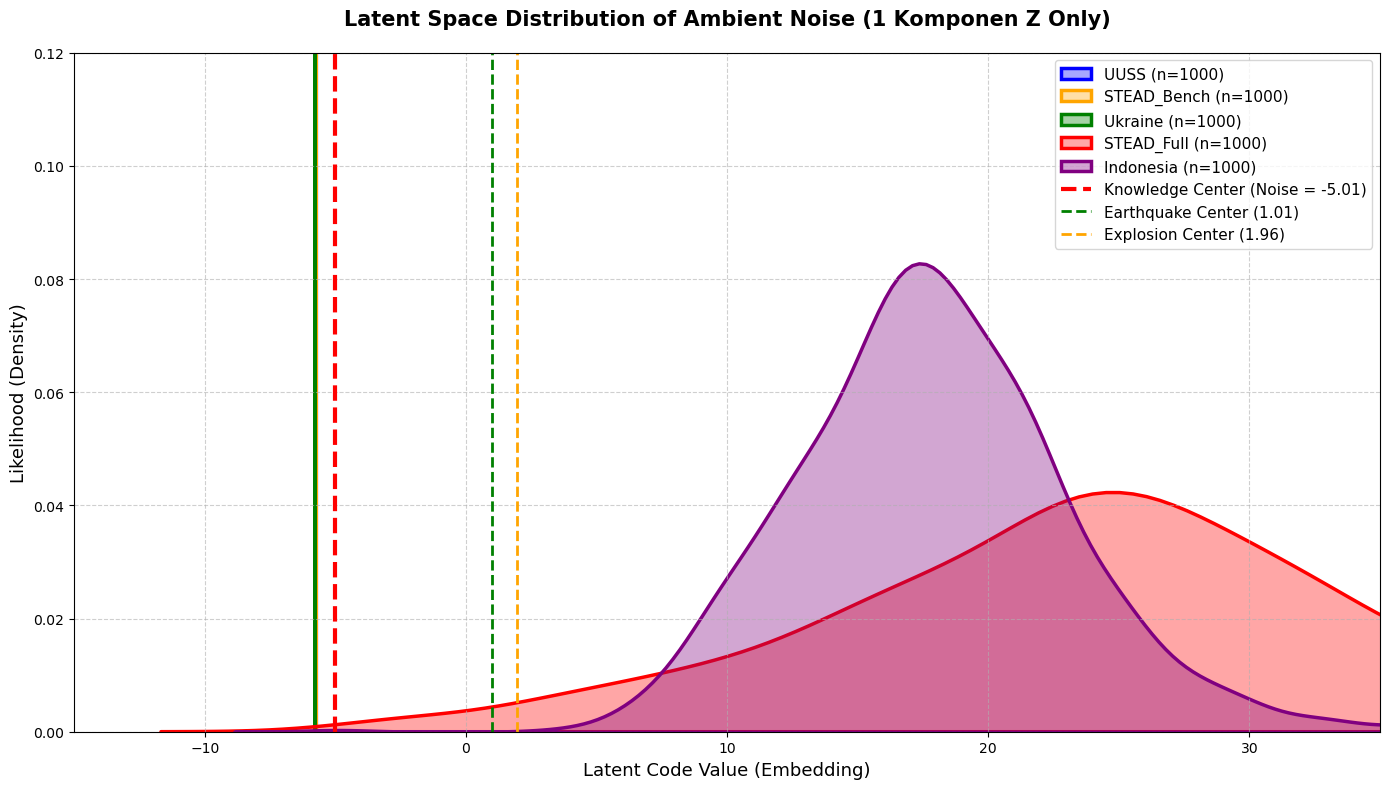


STATISTIK LATENT CODE (Ambient Noise - 1 Komponen Z)
UUSS            | Mean:   -5.778 | Std:  0.002 | Shift:  -0.77
STEAD_Bench     | Mean:   -5.778 | Std:  0.001 | Shift:  -0.77
Ukraine         | Mean:   -5.778 | Std:  0.001 | Shift:  -0.77
STEAD_Full      | Mean:   24.312 | Std: 10.370 | Shift:  29.32
Indonesia       | Mean:   17.875 | Std:  5.240 | Shift:  22.88


In [2]:
# -*- coding: utf-8 -*-
"""
MCU-Quake Latent Space Analysis - Indonesia Noise Misalignment
Fokus hanya pada 1 Komponen Vertikal (Z) - Sesuai Zhi Geng
"""

import json
import numpy as np
import glob
import os
import h5py
import pandas as pd
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.signal as signal

# ==============================================================================
# 1. CONFIGURATION & PATHS
# ==============================================================================
MODEL_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20'

DATA_MAP = {
    "UUSS": r'/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json',
    "STEAD_Bench": '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json',
    "Ukraine": '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ Ukraine 3C_ test n1335 r100 sdb8-956/Ukraine data, test n1335 r100 sdb8-956.json'
}

STEAD_CSV = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'
STEAD_HDF5 = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.hdf5'
DIR_NOISE_INDO = r'/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/indonesia_waveform_master_data/output_data_npypure_1c_noise_9s'

TARGET_SAMPLES = 1000
TARGET_LENGTH = 700  # 7 detik @ 100 Hz

# ==============================================================================
# 2. PREPROCESSING (1 Komponen Z - Sesuai Zhi Geng)
# ==============================================================================
def zhi_geng_preprocess(wave, explicit_norm=None):
    """
    Preprocessing hanya untuk 1 komponen Z:
    - Detrending
    - Resampling ke 100 Hz (700 sampel)
    - Normalization 9-second window
    """
    wave = np.asarray(wave, dtype=np.float32).flatten()  # Pastikan 1D
    
    if len(wave) == 0:
        return np.zeros(TARGET_LENGTH, dtype=np.float32)
    
    # 1. Detrending
    wave = wave - np.mean(wave)
    
    # 2. Resampling ke 100 Hz
    if len(wave) != TARGET_LENGTH:
        wave = signal.resample(wave, TARGET_LENGTH)
    
    # 3. Normalization
    if explicit_norm is not None:
        norm_val = float(explicit_norm)
    else:
        window_size = min(900, len(wave))
        norm_val = np.max(np.abs(wave[-window_size:]))
        norm_val = norm_val if norm_val > 0 else 1e-8
    
    return (wave / norm_val).astype(np.float32)


# ==============================================================================
# 3. DATA LOADING (Hanya Komponen Z)
# ==============================================================================

def load_json_noise_z(path, target, domain_name):
    print(f"[INFO] Loading Z-noise from JSON: {domain_name}...")
    with open(path, 'r') as f:
        data = json.load(f)
    
    samples = []
    keys = list(data.keys())
    np.random.shuffle(keys)
    
    for k in keys:
        trace_data = data[k]
        if "Z_noise" in trace_data:
            try:
                z_noise = np.array(trace_data["Z_noise"], dtype=np.float32)
                if len(z_noise) >= 100:
                    exact_norm = trace_data.get("norm")
                    z_processed = zhi_geng_preprocess(z_noise, explicit_norm=exact_norm)
                    samples.append(z_processed)
                    if len(samples) >= target:
                        break
            except:
                continue
    
    print(f"[INFO] Berhasil load {len(samples)} sampel Z-noise dari {domain_name}")
    return np.array(samples)


def load_stead_large_noise_z(csv_path, h5_path, target):
    print(f"[INFO] Loading Z-noise from STEAD Full...")
    df = pd.read_csv(csv_path, usecols=['trace_name', 'trace_category'])
    noise_names = df[df['trace_category'] == 'noise']['trace_name'].sample(
        n=int(target * 1.5), random_state=42).tolist()
    
    samples = []
    with h5py.File(h5_path, 'r') as f:
        data_group = f['data']
        for name in noise_names:
            if name in data_group:
                try:
                    wave = data_group[name][()]
                    z_noise = wave[:, 2].astype(np.float32)   # Hanya Z component
                    if len(z_noise) >= 100:
                        z_processed = zhi_geng_preprocess(z_noise)
                        samples.append(z_processed)
                        if len(samples) >= target:
                            break
                except:
                    continue
    
    print(f"[INFO] Berhasil load {len(samples)} sampel Z-noise dari STEAD Full")
    return np.array(samples)


def load_indo_noise_z(dir_path, target):
    print(f"[INFO] Loading Z-noise from Indonesia (1C)...")
    files = glob.glob(os.path.join(dir_path, "*.npy"))
    np.random.shuffle(files)
    
    samples = []
    for f in files:
        try:
            wave = np.load(f).astype(np.float32)
            # Karena folder 1C, kita anggap wave sudah 1D atau 2D dengan satu channel
            if wave.ndim == 1 and len(wave) >= 100:
                z_noise = wave
            elif wave.ndim == 2 and wave.shape[1] == 1 and wave.shape[0] >= 100:
                z_noise = wave[:, 0]
            else:
                continue

            z_processed = zhi_geng_preprocess(z_noise)
            samples.append(z_processed)
            if len(samples) >= target:
                break
        except Exception:
            continue
    
    print(f"[INFO] Berhasil load {len(samples)} sampel Z-noise dari Indonesia")
    return np.array(samples)



# ==============================================================================
# 4. INFERENCE
# ==============================================================================
def get_official_embeddings(model_folder, data_dict):
    print(f"\n[INFO] Memuat model MCU-Quake dari: {model_folder}")
    model = tf.saved_model.load(model_folder)
    infer = model.signatures["serving_default"]
    
    latent_results = {}
    for domain, waves in data_dict.items():
        if len(waves) == 0:
            continue
        print(f"[INFO] Ekstraksi latent embedding untuk {domain} (1 komponen Z)...")
        data_tensor = tf.convert_to_tensor(waves.reshape(-1, TARGET_LENGTH, 1), dtype=tf.float32)
        outputs = infer(data_tensor)
        output_key = list(outputs.keys())[0]
        latent_results[domain] = outputs[output_key].numpy().flatten()
        print(f"   → Shape: {latent_results[domain].shape} | Mean: {np.mean(latent_results[domain]):.3f}")
    
    return latent_results


# ==============================================================================
# 5. MAIN EXECUTION
# ==============================================================================
if __name__ == "__main__":
    all_noise_data = {}
    
    for name, path in DATA_MAP.items():
        all_noise_data[name] = load_json_noise_z(path, TARGET_SAMPLES, name)
    
    all_noise_data["STEAD_Full"] = load_stead_large_noise_z(STEAD_CSV, STEAD_HDF5, TARGET_SAMPLES)
    all_noise_data["Indonesia"] = load_indo_noise_z(DIR_NOISE_INDO, TARGET_SAMPLES)
    
    latent_results = get_official_embeddings(MODEL_PATH, all_noise_data)
    
    # ==============================================================================
    # 6. VISUALISASI
    # ==============================================================================
    plt.figure(figsize=(14, 8))
    colors = ['blue', 'orange', 'green', 'red', 'purple']
    
    for i, (domain, codes) in enumerate(latent_results.items()):
        if len(codes) > 0:
            sns.kdeplot(codes, label=f"{domain} (n={len(codes)})", 
                        fill=True, alpha=0.35, linewidth=2.5, color=colors[i])
    
    plt.axvline(x=-5.01, color='red', linestyle='--', linewidth=3, 
                label='Knowledge Center (Noise = -5.01)')
    plt.axvline(x=1.01, color='green', linestyle='--', linewidth=2, 
                label='Earthquake Center (1.01)')
    plt.axvline(x=1.96, color='orange', linestyle='--', linewidth=2, 
                label='Explosion Center (1.96)')
    
    plt.title("Latent Space Distribution of Ambient Noise (1 Komponen Z Only)", 
              weight='bold', fontsize=15, pad=20)
    plt.xlabel("Latent Code Value (Embedding)", fontsize=13)
    plt.ylabel("Likelihood (Density)", fontsize=13)
    
    plt.xlim(-15, 35)
    plt.ylim(0, 0.12)
    plt.legend(loc='upper right', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    plt.savefig("latent_misalignment_noise_indonesia_Z_only.png", dpi=400, bbox_inches='tight')
    plt.show()
    
    # Statistik
    print("\n" + "="*70)
    print("STATISTIK LATENT CODE (Ambient Noise - 1 Komponen Z)")
    print("="*70)
    for domain, codes in latent_results.items():
        mean_val = np.mean(codes)
        std_val = np.std(codes)
        shift = mean_val + 5.01
        print(f"{domain:15} | Mean: {mean_val:8.3f} | Std: {std_val:6.3f} | Shift: {shift:6.2f}")

[INFO] Loading Z-noise from JSON: UUSS...
[INFO] Berhasil load 1000 sampel Z-noise dari UUSS
[INFO] Loading Z-noise from JSON: STEAD_Bench...
[INFO] Berhasil load 1000 sampel Z-noise dari STEAD_Bench
[INFO] Loading Z-noise from JSON: Ukraine...
[INFO] Berhasil load 1000 sampel Z-noise dari Ukraine
[INFO] Loading Z-noise from STEAD Full...
[INFO] Berhasil load 1000 sampel Z-noise dari STEAD Full
[INFO] Loading Z-noise from Indonesia (1C)...
[INFO] Berhasil load 1000 sampel Z-noise dari Indonesia

[INFO] Memuat model MCU-Quake dari: /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20
[INFO] Ekstraksi latent embedding untuk UUSS (1 komponen Z)...
   → Shape: (1000,) | Mean: -5.778
[INFO] Ekstraksi latent embedding untuk STEAD_Bench (1 komponen Z)...
   → Shape: (1000,) | Mean: -5.778
[INFO] Ekstraksi latent embedding untuk Ukraine (1 komponen Z)...
   → Shape: (1000,) |

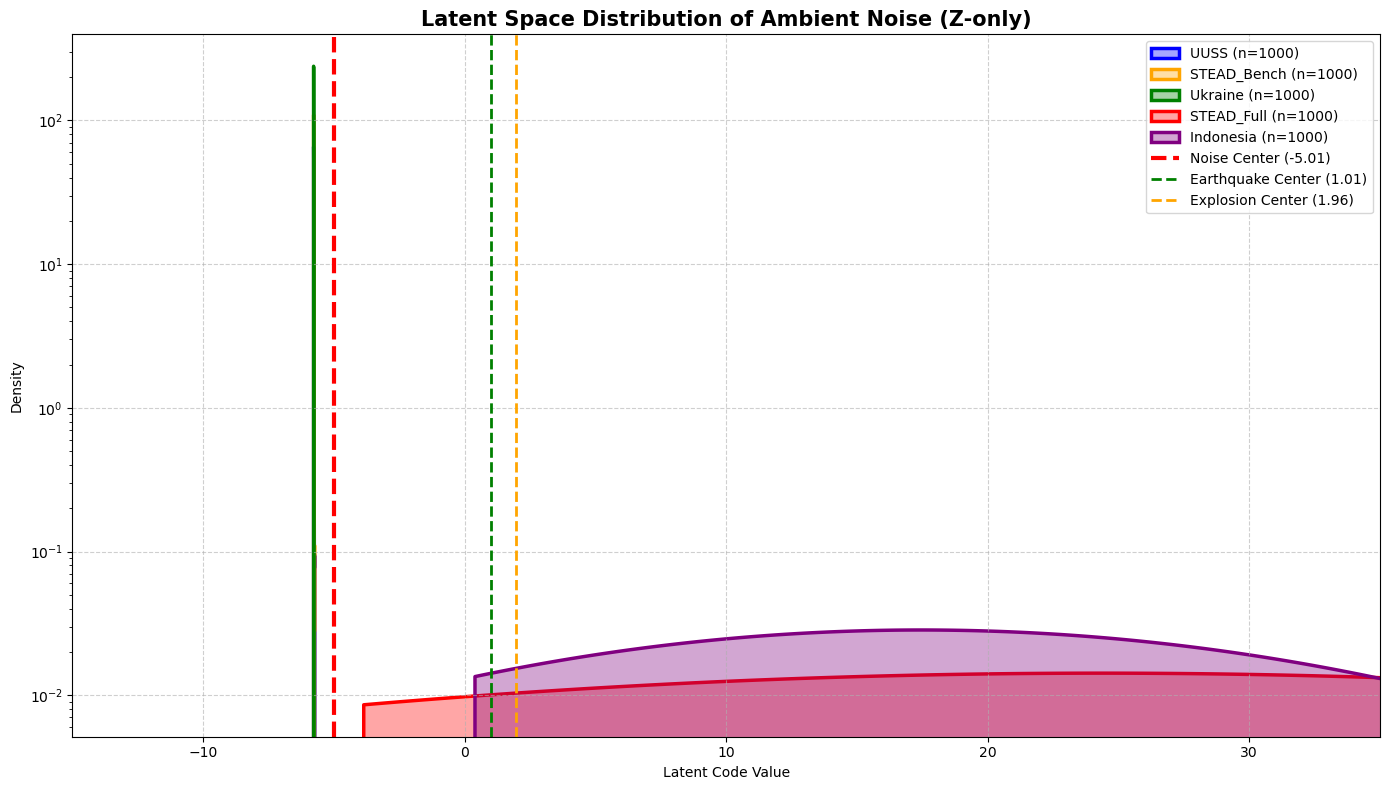

In [3]:
# -*- coding: utf-8 -*-
"""
MCU-Quake Latent Space Analysis - Indonesia Noise Misalignment
Fokus hanya pada 1 Komponen Vertikal (Z) - Sesuai Zhi Geng (konsep: 1C, 7 s, 1 nilai embedding)
"""

import json
import numpy as np
import glob
import os
import h5py
import pandas as pd
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.signal as signal

# ==============================================================================
# 1. CONFIGURATION & PATHS
# ==============================================================================
MODEL_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20'

DATA_MAP = {
    "UUSS": r'/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json',
    "STEAD_Bench": '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ STEAD 3C_ test n15275 r100/STEAD data, test n15275 r100.json',
    "Ukraine": '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Benchmark_ Ukraine 3C_ test n1335 r100 sdb8-956/Ukraine data, test n1335 r100 sdb8-956.json'
}

STEAD_CSV = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'
STEAD_HDF5 = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.hdf5'
# ← sekarang benar-benar 1C, jadi loader harus 1C juga
DIR_NOISE_INDO = r'/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/indonesia_waveform_master_data/output_data_npypure_1c_noise_9s'

TARGET_SAMPLES = 1000
TARGET_LENGTH = 700  # 7 detik @ 100 Hz

# ==============================================================================
# 2. PREPROCESSING (1 Komponen Z)
# ==============================================================================
def zhi_geng_preprocess(wave, explicit_norm=None):
    """
    Preprocessing hanya untuk 1 komponen Z:
    - Detrending
    - Resampling ke 100 Hz (700 sampel)
    - Normalization 9-second window (implementasi lokal)
    """
    wave = np.asarray(wave, dtype=np.float32).flatten()  # Pastikan 1D
    
    if len(wave) == 0:
        return np.zeros(TARGET_LENGTH, dtype=np.float32)
    
    # 1. Detrending
    wave = wave - np.mean(wave)
    
    # 2. Resampling ke 100 Hz
    if len(wave) != TARGET_LENGTH:
        wave = signal.resample(wave, TARGET_LENGTH)
    
    # 3. Normalization
    if explicit_norm is not None:
        norm_val = float(explicit_norm)
    else:
        window_size = min(900, len(wave))
        norm_val = np.max(np.abs(wave[-window_size:]))
        norm_val = norm_val if norm_val > 0 else 1e-8
    
    return (wave / norm_val).astype(np.float32)


# ==============================================================================
# 3. DATA LOADING (Hanya Komponen Z)
# ==============================================================================
def load_json_noise_z(path, target, domain_name):
    print(f"[INFO] Loading Z-noise from JSON: {domain_name}...")
    with open(path, 'r') as f:
        data = json.load(f)
    
    samples = []
    keys = list(data.keys())
    np.random.shuffle(keys)
    
    for k in keys:
        trace_data = data[k]
        if "Z_noise" in trace_data:
            try:
                z_noise = np.array(trace_data["Z_noise"], dtype=np.float32)
                if len(z_noise) >= 100:
                    exact_norm = trace_data.get("norm")
                    z_processed = zhi_geng_preprocess(z_noise, explicit_norm=exact_norm)
                    samples.append(z_processed)
                    if len(samples) >= target:
                        break
            except Exception:
                continue
    
    print(f"[INFO] Berhasil load {len(samples)} sampel Z-noise dari {domain_name}")
    return np.array(samples)


def load_stead_large_noise_z(csv_path, h5_path, target):
    print(f"[INFO] Loading Z-noise from STEAD Full...")
    df = pd.read_csv(csv_path, usecols=['trace_name', 'trace_category'])
    noise_names = df[df['trace_category'] == 'noise']['trace_name'].sample(
        n=int(target * 1.5), random_state=42).tolist()
    
    samples = []
    with h5py.File(h5_path, 'r') as f:
        data_group = f['data']
        for name in noise_names:
            if name in data_group:
                try:
                    wave = data_group[name][()]
                    # Tetap pakai [:, 2] sesuai pipeline kamu; kalau metadata bilang Z di [:,0], ini yang perlu diubah
                    z_noise = wave[:, 2].astype(np.float32)
                    if len(z_noise) >= 100:
                        z_processed = zhi_geng_preprocess(z_noise)
                        samples.append(z_processed)
                        if len(samples) >= target:
                            break
                except Exception:
                    continue
    
    print(f"[INFO] Berhasil load {len(samples)} sampel Z-noise dari STEAD Full")
    return np.array(samples)


def load_indo_noise_z(dir_path, target):
    print(f"[INFO] Loading Z-noise from Indonesia (1C)...")
    files = glob.glob(os.path.join(dir_path, "*.npy"))
    np.random.shuffle(files)
    
    samples = []
    for f in files:
        try:
            wave = np.load(f).astype(np.float32)
            # Karena folder 1C, kita anggap wave sudah 1D atau 2D dengan satu channel
            if wave.ndim == 1 and len(wave) >= 100:
                z_noise = wave
            elif wave.ndim == 2 and wave.shape[1] == 1 and wave.shape[0] >= 100:
                z_noise = wave[:, 0]
            else:
                continue

            z_processed = zhi_geng_preprocess(z_noise)
            samples.append(z_processed)
            if len(samples) >= target:
                break
        except Exception:
            continue
    
    print(f"[INFO] Berhasil load {len(samples)} sampel Z-noise dari Indonesia")
    return np.array(samples)


# ==============================================================================
# 4. INFERENCE
# ==============================================================================
def get_official_embeddings(model_folder, data_dict):
    print(f"\n[INFO] Memuat model MCU-Quake dari: {model_folder}")
    model = tf.saved_model.load(model_folder)
    infer = model.signatures["serving_default"]
    
    latent_results = {}
    for domain, waves in data_dict.items():
        if len(waves) == 0:
            continue
        print(f"[INFO] Ekstraksi latent embedding untuk {domain} (1 komponen Z)...")
        data_tensor = tf.convert_to_tensor(
            waves.reshape(-1, TARGET_LENGTH, 1), dtype=tf.float32
        )
        outputs = infer(data_tensor)
        output_key = list(outputs.keys())[0]
        emb = outputs[output_key].numpy().flatten()  # 1 nilai per waveform
        latent_results[domain] = emb
        print(f"   → Shape: {emb.shape} | Mean: {np.mean(emb):.3f}")
    
    return latent_results


# ==============================================================================
# 5. MAIN EXECUTION
# ==============================================================================
if __name__ == "__main__":
    all_noise_data = {}
    
    for name, path in DATA_MAP.items():
        all_noise_data[name] = load_json_noise_z(path, TARGET_SAMPLES, name)
    
    all_noise_data["STEAD_Full"] = load_stead_large_noise_z(
        STEAD_CSV, STEAD_HDF5, TARGET_SAMPLES
    )
    all_noise_data["Indonesia"] = load_indo_noise_z(
        DIR_NOISE_INDO, TARGET_SAMPLES
    )
    
    latent_results = get_official_embeddings(MODEL_PATH, all_noise_data)
    
    # ==============================================================================
    # 6. VISUALISASI (DIPERJELAS)
    # ==============================================================================
    # ==============================================================================
# 6. VISUALISASI (DIPERBAIKI AGAR BUKIT TERLIHAT)
# ==============================================================================

    plt.figure(figsize=(14, 8))
    colors = ['blue', 'orange', 'green', 'red', 'purple']

    for i, (domain, codes) in enumerate(latent_results.items()):
        if len(codes) > 0:
            sns.kdeplot(
                codes,
                label=f"{domain} (n={len(codes)})",
                fill=True,
                alpha=0.35,
                linewidth=2.5,
                color=colors[i % len(colors)],
                bw_adjust=10,     # ← KUNCI UTAMA: memperlebar bukit
                cut=0,            # ← mencegah KDE melebar terlalu jauh
                clip=(-20, 40),   # ← membatasi area KDE agar stabil
            )

    # Knowledge centers
    plt.axvline(x=-5.01, color='red', linestyle='--', linewidth=3, label='Noise Center (-5.01)')
    plt.axvline(x=1.01, color='green', linestyle='--', linewidth=2, label='Earthquake Center (1.01)')
    plt.axvline(x=1.96, color='orange', linestyle='--', linewidth=2, label='Explosion Center (1.96)')

    plt.title("Latent Space Distribution of Ambient Noise (Z-only)", fontsize=15, weight='bold')
    plt.xlabel("Latent Code Value")
    plt.ylabel("Density")

    plt.xlim(-15, 35)
    plt.yscale("log")      # ← membuat bukit kecil tetap terlihat
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper right')
    plt.tight_layout()

    plt.savefig("latent_misalignment_noise_indonesia_Z_only.png", dpi=400, bbox_inches='tight')
    plt.show()
